In [1]:
import numpy as np
import matplotlib.pyplot as pp
import math
from textwrap import dedent

from mccode_antlr import Flavor
from mccode_antlr.reader.registry import InMemoryRegistry
from mccode_antlr.assembler import Assembler
from mccode_antlr.common import Expr
from mccode_antlr.run import McStas

In [2]:
def repo_registry():
    """Return a LocalRegistry pointing at the root of this git repository."""
    from git import Repo, InvalidGitRepositoryError
    from mccode_antlr.reader.registry import LocalRegistry
    try:
        repo = Repo('.', search_parent_directories=True)
        return LocalRegistry('monochromator_rowland', repo.working_tree_dir)
    except InvalidGitRepositoryError as exc:
        raise RuntimeError(f"Could not locate repository root: {exc}") from exc

In [3]:
src_reg = InMemoryRegistry('testing_reg')
src_reg.add_comp('DivergentSource', dedent("""
    DEFINE COMPONENT DivergentSource
    SETTING PARAMETERS (double velocity=2200.0, double dv_deg=25.0, double dh_deg=5.0)
    TRACE
    %{
      double angle = (2.0*rand01() - 1.0) * DEG2RAD * dh_deg;
      double yang = (2.0*rand01() - 1.0) * DEG2RAD * dv_deg;
      double vel = (0.9 + 0.5 * rand01()) * velocity;
      x = 0; y = 0; z = 0;
      vx = vel * sin(angle) * cos(yang);
      vy = vel * sin(angle) * sin(yang);
      vz = vel * cos(angle);
      t = 0.0;
      p = 1.0;
      SCATTER;
    %}
    END
"""))


In [4]:
# ---------------------------------------------------------------------------
# Test instrument geometry constants
# ---------------------------------------------------------------------------


# PG 002 lattice spacing (Å)
_DM = 3.355
# 2θ = 80° → θ_B = 40°
_TWO_THETA_DEG = 80.0
_THETA_B_DEG = _TWO_THETA_DEG / 2.0          # 40°
_THETA_B_RAD = math.radians(_THETA_B_DEG)
# Bragg condition: λ = 2·d·sin(θ_B)
_LAMBDA_BRAGG = 2.0 * _DM * math.sin(_THETA_B_RAD)   # Å
# Neutron speed at that wavelength (v = 3956 / λ [Å] m/s)
_V_BRAGG = 3956.0 / _LAMBDA_BRAGG                    # m/s  ≈ 918 m/s

In [5]:


asm = Assembler('focus_test', registries=[repo_registry(), src_reg], flavor=Flavor.MCSTAS)
asm.component('origin', 'DivergentSource', at=(0, 0, 0), parameters={
    'velocity': _V_BRAGG,
    'dv_deg': 2 * math.atan2(0.15, 1.0) * 180 / math.pi,
})
asm.component('analyzer_point', 'Arm', at=((0,0,1), 'origin'))
asm.component('monitor', 'PSD_monitor', at=([0,0,1e-3], 'PREVIOUS'), 
              parameters={
                  'nx': 100, 
                  'ny': 20, 
                  'restore_neutron': 1,
                  'yheight': 0.3,
                  'xwidth': 0.1,
              })
asm.parameter('double focpow = 1')
asm.component('analyzer', 'Monochromator_Rowland', at=((0,0,0), 'analyzer_point'), 
              rotate=([0,_THETA_B_DEG,0], 'analyzer_point'), parameters={
                  'NH': 7,
                  'zwidth': 0.01,
                  'yheight': 0.15,
                  'mosaic': 60.0,
                  'DM': _DM,
                  'gap': 0.002,
                  'source': '"origin"',
                  'sink': '"focus"',
                  'focush': '"exact"',
                  'tiltH_scale': Expr.parameter('focpow'),
                  'verbose': 0,
              })
asm.component('detector_arm', 'Arm', at=((0,0,0), 'analyzer'), rotate=((0,_TWO_THETA_DEG,0), 'analyzer_point'))
asm.component('focus', 'Arm', at=((0,0,1), 'detector_arm'))
asm.component('detector', 'PSD_monitor', at=([0,0,0], 'focus'), 
              parameters={
                  'nx': 20, 
                  'ny': 20, 
                  'restore_neutron': 1,
                  'yheight': 0.3,
                  'xwidth': 0.005,
              })
asm.component('overflow', 'PSD_monitor', at=([0,0,1e-3], 'focus'), 
              parameters={
                  'nx': 100, 
                  'ny': 20, 
                  'restore_neutron': 1,
                  'yheight': 0.3,
                  'xwidth': 0.05,
              })
asm.instrument

2026-03-14 17:09:21.854 | DEBUG    | mccode_antlr.reader.reader:add_component:243 - Component cache hit: /home/g/.cache/mccodeantlr/mcstas/v3.5.31/mcstas-comps/optics/Arm.comp
2026-03-14 17:09:21.879 | DEBUG    | mccode_antlr.reader.reader:add_component:243 - Component cache hit: /home/g/.cache/mccodeantlr/mcstas/v3.5.31/mcstas-comps/monitors/PSD_monitor.comp
2026-03-14 17:09:21.916 | DEBUG    | mccode_antlr.reader.reader:add_component:243 - Component cache hit: /home/g/Code/mccode/mcstas-monochromator-rowland/Monochromator_Rowland.comp


Instr(name='focus_test', source='interactive', parameters=(InstrumentParameter(name='focpow', unit=None, value=scalar 1 Integer(1)),), metadata=(), components=(Instance(origin, DivergentSource), Instance(analyzer_point, Arm), Instance(monitor, PSD_monitor), Instance(analyzer, Monochromator_Rowland), Instance(detector_arm, Arm), Instance(focus, Arm), Instance(detector, PSD_monitor), Instance(overflow, PSD_monitor)), included=(), user=(), declare=(), initialize=(), save=(), final=(), registries=[<mccode_antlr.reader.registry.InMemoryRegistry object at 0x7f3c24119fd0>, LocalRegistry('monochromator_rowland', PosixPath('/home/g/Code/mccode/mcstas-monochromator-rowland'), 10), <mccode_antlr.reader.registry.GitHubRegistry object at 0x7f3bcaad3c50>, <mccode_antlr.reader.registry.GitHubRegistry object at 0x7f3bca966a50>], dependency=(), flow_edges=(FlowEdgeRecord(src='origin', dst='analyzer_point', edge=SequentialEdge(when=None)), FlowEdgeRecord(src='analyzer_point', dst='monitor', edge=SequentialEdge(when=None)), FlowEdgeRecord(src='monitor', dst='analyzer', edge=SequentialEdge(when=None)), FlowEdgeRecord(src='analyzer', dst='detector_arm', edge=SequentialEdge(when=None)), FlowEdgeRecord(src='detector_arm', dst='focus', edge=SequentialEdge(when=None)), FlowEdgeRecord(src='focus', dst='detector', edge=SequentialEdge(when=None)), FlowEdgeRecord(src='detector', dst='overflow', edge=SequentialEdge(when=None))))

In [6]:
sim = McStas(asm.instrument)
sim.compile()

2026-03-14 17:09:21.959 | DEBUG    | mccode_antlr.reader.reader:add_component:243 - Component cache hit: /home/g/.cache/mccodeantlr/mcstas/v3.5.31/mcstas-comps/optics/Arm.comp


No initialization present?

-----------------------------------------------------------

Generating single GPU kernel or single CPU section layout:

-----------------------------------------------------------

Generating GPU/CPU -DFUNNEL layout:
-> GPU kernel from component a

-----------------------------------------------------------


2026-03-14 17:09:23.006 | INFO     | mccode_antlr.compiler.c:_compile_instrument:201 - Compile focus_test


No initialization present?

-----------------------------------------------------------

Generating single GPU kernel or single CPU section layout:

-----------------------------------------------------------

Generating GPU/CPU -DFUNNEL layout:
-> GPU kernel from component origin
-> GPU kernel from component analyzer_point
-> GPU kernel from component monitor
-> GPU kernel from component analyzer
-> GPU kernel from component detector_arm
-> GPU kernel from component focus
-> GPU kernel from component detector
-> GPU kernel from component overflow

-----------------------------------------------------------


In [7]:
focpow = np.arange(-1, 3.1, 0.1)
res = sim.scan(ncount=500000, parameters={'focpow': [float(x) for x in focpow]})

In [8]:
#[l for r in res for l in r[0].decode().splitlines()]

In [9]:
dat =  [r[1] for r in res]

In [10]:
detector = [d['detector'] for d in dat]

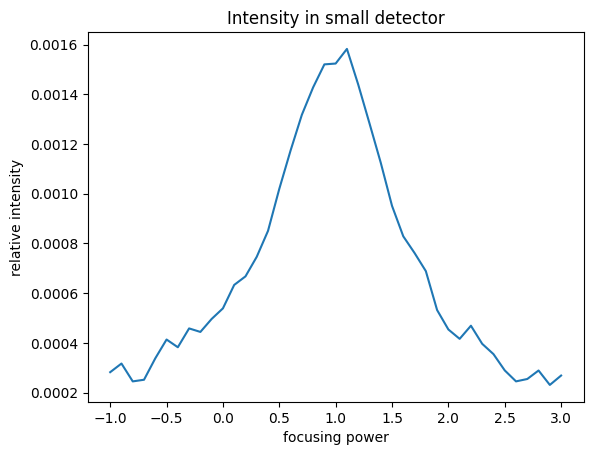

In [11]:
pp.plot(focpow, [d['detector']['I'].sum() / d['monitor']['I'].sum() for d in dat])
pp.setp(pp.gca(), xlabel='focusing power', ylabel='relative intensity', title='Intensity in small detector');

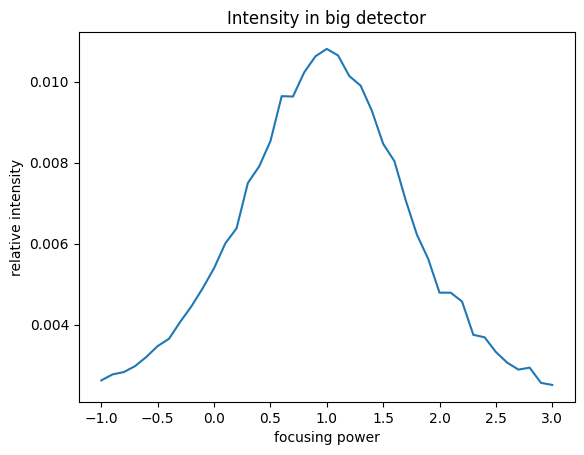

In [12]:
pp.plot(focpow, [d['overflow']['I'].sum() / d['monitor']['I'].sum() for d in dat])
pp.setp(pp.gca(), xlabel='focusing power', ylabel='relative intensity', title='Intensity in big detector');

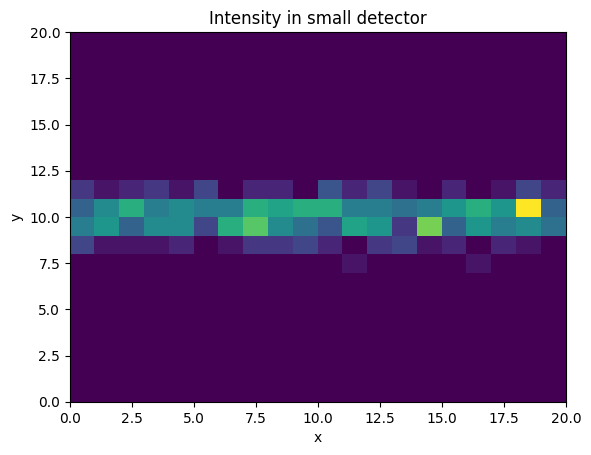

In [13]:
pp.pcolor(dat[20]['detector']['I'])
pp.setp(pp.gca(), xlabel='x', ylabel='y', title='Intensity in small detector');

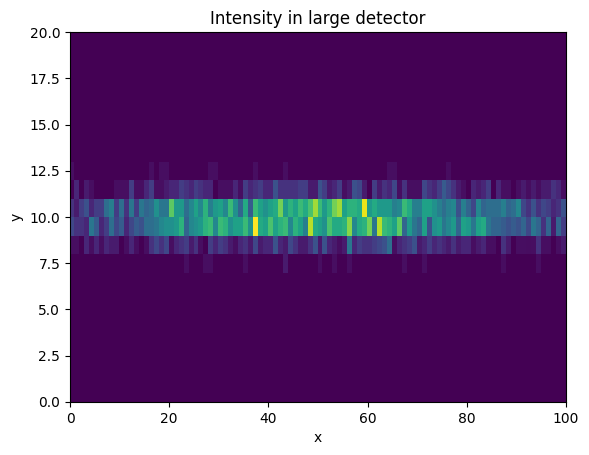

In [14]:
pp.pcolor(dat[20]['overflow']['I'])
pp.setp(pp.gca(), xlabel='x', ylabel='y', title='Intensity in large detector');